In [76]:
DISEASE = input("Disease: ")
average_t = [2,4,6,8]
interlayer_transition_prob = 0.35
num_neighbors = 400

# Import

In [74]:
# ----------------------------
# Standard library
# ----------------------------
import gc
import json
import os
import pickle
import sys
from collections import Counter, defaultdict
from pathlib import Path
from tempfile import NamedTemporaryFile

# ----------------------------
# Core scientific stack
# ----------------------------
import numpy as np
import pandas as pd

import scipy.sparse as sp
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import linear_sum_assignment
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import LinearOperator, eigsh, lobpcg

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------
# Progress / memory profiling
# ----------------------------
from tqdm import tqdm
from pympler import asizeof, muppy

# ----------------------------
# Graph / community detection
# ----------------------------
import igraph as ig
import leidenalg as la
import networkx as nx
import community as community_louvain

# ----------------------------
# PDF utilities
# ----------------------------
from pypdf import PdfReader, PdfWriter

# ----------------------------
# ML / embedding
# ----------------------------
import umap
from sklearn.metrics import adjusted_rand_score


# Building Multilayer Transition Matrix

In [75]:
# Load all the matrices needed
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../../Gen_Hypergraph/output/MSigDB_Full/"

## DGIDB
DGIDB_binary_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
DGIDB_weighted_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
DGIDB_gene_weight_diag_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_gene_weight_matrix.npz")
DGIDB_diag_node_degree_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_node_degree_matrix.npz")
DGIDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )
DGIDB_inverse_diag_edge_degree_weightless_matrix = sp.load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_weightless_matrix.npz"
    )

## MSIGDB
MSIGDB_binary_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
MSIGDB_weighted_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
MSIGDB_gene_weight_diag_matrix = sp.load_npz(MSIGDB_DIRECTORY + "gene_weight_diag_matrix.npz")
MSIGDB_diag_node_degree_matrix = sp.load_npz(MSIGDB_DIRECTORY + "diag_node_degree_matrix.npz")
MSIGDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    MSIGDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

FileNotFoundError: [Errno 2] No such file or directory: '../../Gen_Hypergraph/output/DGIDB_/hypergraph_incidence_matrix_binary.npz'

In [ ]:
# Useful Functions
def csr_equal_tol(A, B, atol=1e-8):
    # First check shapes and sparsity pattern
    if A.shape != B.shape or not np.array_equal(A.indptr, B.indptr) or not np.array_equal(A.indices, B.indices):
        return False
    # Compare numeric values within tolerance
    return np.allclose(A.data, B.data, atol=atol, rtol=0)


# row stochastic check
def row_stochastic_check(A):
    row_sums = np.array(A.sum(axis=1)).ravel()
    print(row_sums)
    ok = np.all(np.isclose(row_sums, 1.0))
    print("Every row sums to 1?", ok)
    return ok

def is_symmetric(W,tol = 1e-12):
    diff = (W - W.T)
    if len(np.abs(diff.data)) == 0:
        print("Matrix is exactly symmetric.")
        return True
    else:
        check = np.all(np.abs(diff.data) < tol)
        print(max(np.abs(diff.data)))
    return check

def degree_array(A, a=1):
    return np.asarray(A.sum(axis=a)).ravel()

def degree_diagonal_matrix(W, a=1):
    d = degree_array(W,a)
    return sp.diags(d, offsets=0, format='csr')

def symmetrically_normalize(W, a=1):
    D = np.asarray(W.sum(axis=a)).ravel()
    D_inv_sqrt = np.zeros_like(D)
    nze = D != 0
    D_inv_sqrt[nze] = 1 / np.sqrt(D[nze])

    W_sym = W.multiply(D_inv_sqrt)              # scale columns
    W_sym = W_sym.multiply(D_inv_sqrt[:, None]) # scale rows    
    return W_sym.tocsr()

def big_objects(n=10, min_mb=1):
    """
    Show the largest objects currently in memory.
    
    Parameters
    ----------
    n : int
        Number of top objects to show.
    min_mb : float
        Minimum size (in MB) to include.
    """
    import sys
    import numpy as np
    import pandas as pd
    import scipy.sparse as sp
    from IPython import get_ipython

    def get_size(obj):
        try:
            if isinstance(obj, np.ndarray):
                return obj.nbytes
            elif isinstance(obj, pd.DataFrame) or isinstance(obj, pd.Series):
                return obj.memory_usage(deep=True).sum()
            elif sp.issparse(obj):
                return (obj.data.nbytes +
                        obj.indptr.nbytes +
                        obj.indices.nbytes)
            else:
                return sys.getsizeof(obj)
        except Exception:
            return 0

    ip = get_ipython()
    if ip is None:
        ns = globals()
    else:
        ns = ip.user_ns

    items = []
    for name, val in ns.items():
        if name.startswith('_'):
            continue  # skip internals
        size = get_size(val)
        if size > min_mb * 1024 ** 2:
            items.append((name, type(val).__name__, size))

    items.sort(key=lambda x: x[2], reverse=True)

    print(f"{'Variable':30s} {'Type':25s} {'Size (MB)':>10s}")
    print("-" * 70)
    for name, t, size in items[:n]:
        print(f"{name:30s} {t:25s} {size / 1024 ** 2:10.2f}")
        
def relative_normality_error(A):
    if sp.issparse(A):
        AH = A.getH()
        AAH = A @ AH
        AHA = AH @ A
        C = AAH - AHA

        num = np.sqrt(np.sum(np.abs(C.data)**2))
        den = max(
            np.sqrt(np.sum(np.abs(AAH.data)**2)),
            np.sqrt(np.sum(np.abs(AHA.data)**2)),
            1e-30
        )
        return num / den
    else:
        AH = A.conj().T
        AAH = A @ AH
        AHA = AH @ A
        return np.linalg.norm(AAH - AHA, 'fro') / max(
            np.linalg.norm(AAH, 'fro'),
            np.linalg.norm(AHA, 'fro'),
            1e-30
        )

In [ ]:
# Building Adjacency Matrices

## DGIDB
H,W_v,D_v,D_e_inv, H_bin = DGIDB_weighted_matrix, DGIDB_gene_weight_diag_matrix, DGIDB_diag_node_degree_matrix, DGIDB_inverse_diag_edge_degree_matrix, DGIDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

DGIDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T



In [ ]:
# ## MSIGDB
H,W_v,D_v,D_e_inv, H_bin = MSIGDB_weighted_matrix, MSIGDB_gene_weight_diag_matrix, MSIGDB_diag_node_degree_matrix, MSIGDB_inverse_diag_edge_degree_matrix, MSIGDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

MSIGDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T

In [ ]:
assert(row_stochastic_check(DGIDB_adjacency_matrix))
assert(row_stochastic_check(MSIGDB_adjacency_matrix))

[1.0000001  0.9999999  1.         1.         1.         1.0000001
 1.         0.9999999  1.         0.99999994 1.         1.
 1.         0.99999994 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999994 0.99999994 0.99999994 1.         1.
 0.99999994 1.0000001  0.99999994 1.         0.9999999  1.
 1.         1.         0.99999994 1.         1.         1.
 0.99999994 1.0000001  0.99999994 1.         1.         0.99999994
 1.         1.         1.         0.9999999  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.9999999  1.         1.0000001  0.9999998
 0.99999994 1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.9999999  1.         1.0000001  1.         1.         1.
 1.         0.99999994 1.         1.         0.99999994 1.
 1.         1.         0.99999994 0.99999994 1.         1.
 1.         1.         1.         

## coupling matrices

In [ ]:
## Build interlayer coupling matrices between the two layers

dgidb_to_msigdb_indices = []
# Open the JSON file and load its content into a dictionary
with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
    dgidb = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    msigdb = json.load(file)
DGIDB_index_to_gene = {index: gene for gene, index in dgidb.items()}
MSIGDB_index_to_gene = {index: gene for gene, index in msigdb.items()}

num_genes_msigdb = len(msigdb)
num_genes_dgidb = len(dgidb)

# Intialize the inter-layer matrix with zeros
C12 = np.zeros((num_genes_dgidb,num_genes_msigdb))
C21 = np.zeros((num_genes_msigdb,num_genes_dgidb))
B12_array = np.zeros(num_genes_dgidb)
B21_array = np.zeros(num_genes_msigdb)

i = 0
for gene_dgidb, idx_dgidb in dgidb.items():
    # If the gene exists in both gene-to-index mappings
    if gene_dgidb in msigdb:      
        idx_msigdb = msigdb[gene_dgidb]
        dgidb_to_msigdb_indices.append((idx_dgidb, idx_msigdb))
        i += 1
    else:
        dgidb_to_msigdb_indices.append((idx_dgidb, None))
        print(f"Gene {gene_dgidb} not found in MSIGDB mapping.")
        
# build C21 and C12

for idx_dgidb, idx_msigdb in dgidb_to_msigdb_indices:
    if (idx_msigdb is not None):
        C12[idx_dgidb,:] = MSIGDB_adjacency_matrix.getrow(idx_msigdb).toarray().ravel()
        C21[idx_msigdb,:] = DGIDB_adjacency_matrix.getrow(idx_dgidb).toarray().ravel()
        B12_array[idx_dgidb] = interlayer_transition_prob
        B21_array[idx_msigdb] = interlayer_transition_prob

A12_array = 1 - B12_array
A21_array = 1 - B21_array

B12 = sp.diags(B12_array)
B21 = sp.diags(B21_array)
A12 = sp.diags(A12_array)
A21 = sp.diags(A21_array)
# print stat
print(i/len(dgidb), "of DGIDB genes have a match in MSIGDB")
dgidb_to_msigdb_indices_dict = dict(dgidb_to_msigdb_indices)

with open(OUTPUT_DIRECTORY + "dgidb_to_msigdb_indices_dict.json", 'w') as file:
    json.dump(dgidb_to_msigdb_indices_dict, file, indent=4)
print(f"Mappings saved to {OUTPUT_DIRECTORY}dgidb_to_msigdb_indices_dict.json")   

Gene 360158 not found in MSIGDB mapping.
Gene 11 not found in MSIGDB mapping.
Gene 100302144 not found in MSIGDB mapping.
Gene 100302251 not found in MSIGDB mapping.
Gene 79529 not found in MSIGDB mapping.
Gene 236 not found in MSIGDB mapping.
Gene 652991 not found in MSIGDB mapping.
Gene 267012 not found in MSIGDB mapping.
Gene 693167 not found in MSIGDB mapping.
Gene 927 not found in MSIGDB mapping.
0.9721448467966574 of DGIDB genes have a match in MSIGDB
Mappings saved to ../output/BIPOLAR/dgidb_to_msigdb_indices_dict.json


In [ ]:
# build DGIDB_to_real
n1,n2 = num_genes_dgidb,num_genes_msigdb
# dgidb_to_real = []
dgidb_idx = []
gene_to_index_dgidb_new= {}
coupling_matrix = C12
msigdb_idx = np.arange(n1,n1+n2)
num_additional_rows = 0

for didx, midx in dgidb_to_msigdb_indices_dict.items():
    if(midx is None):
        # dgidb_to_real.append(didx)
        dgidb_idx.append(didx) 
        gene_to_index_dgidb_new[DGIDB_index_to_gene[didx]] = num_additional_rows
        num_additional_rows += 1
    # else: 
    #     dgidb_to_real.append(n1 + midx)


    
MSIGDB_gene_to_index_new = {g: i + num_additional_rows for g, i in msigdb.items()}
gene_to_index_distinct = MSIGDB_gene_to_index_new | gene_to_index_dgidb_new

with open(OUTPUT_DIRECTORY + "gene_to_index_distinct.json", 'w') as pathway_file:
    json.dump(gene_to_index_distinct, pathway_file, indent=4)
print(f"Mappings saved to {OUTPUT_DIRECTORY}gene_to_index_distinct.json")    

Mappings saved to ../output/BIPOLAR/gene_to_index_distinct.json


In [ ]:
for u, v in dgidb_to_msigdb_indices_dict.items():
    print(1) if v is None else None

1
1
1
1
1
1
1
1
1
1


## construct MTM

In [ ]:
A = A12 @ DGIDB_adjacency_matrix
B = B12 @ C12
C = B21 @ C21
D = A21 @ MSIGDB_adjacency_matrix

In [ ]:
## Build the multilayer transition matrix
P = sp.bmat([
    [A, B],
    [C, D]
]).tocsr()

num_genes = P.shape[0]
del A, B, C, D
for i in range(3):
    gc.collect()

In [ ]:
assert(row_stochastic_check(P))

[1.00000001 0.99999992 1.         ... 1.         1.         1.        ]
Every row sums to 1? True


In [ ]:
# P is sparse or dense
A = sp.csr_matrix(P > 0)   # support matrix
n_components, labels = connected_components(A, directed=False)

assert(n_components == 1)

## stationary distribution

In [ ]:
def stationary_distribution(W, tol=1e-9, maxit=20000, seed=0):
    # power iteration for left stationary of row-stochastic W
    n = W.shape[0]
    rng = np.random.default_rng(seed)
    pi = rng.random(n) + 1e-12
    pi /= pi.sum()
    for _ in range(maxit):
        pi_next = pi @ W
        if np.linalg.norm(pi_next - pi, 1) < tol:
            break
        pi = pi_next
    return pi / pi.sum()

In [ ]:
pi = stationary_distribution(P)

## understand random walk process

In [ ]:
# extract the four blocks as A,B,C,D
A = P[0:num_genes_dgidb,0:num_genes_dgidb]
B = P[0:num_genes_dgidb,num_genes_dgidb:num_genes_dgidb+num_genes_msigdb]
C = P[num_genes_dgidb:num_genes_dgidb+num_genes_msigdb,0:num_genes_dgidb]
D = P[num_genes_dgidb:num_genes_dgidb+num_genes_msigdb,num_genes_dgidb:num_genes_dgidb+num_genes_msigdb]

In [ ]:
# Find rows of C with nonzero row sum
replicate_idx_msigdb = np.where(C.sum(axis=1) != 0)[0]
replicate_idx_dgidb = np.where(B.sum(axis=1) != 0)[0]

In [ ]:
A_sel,B_sel,C_sel,D_sel = A[replicate_idx_dgidb,:], B[replicate_idx_dgidb,:], C[replicate_idx_msigdb,:], D[replicate_idx_msigdb,:]

In [ ]:
# average row sum of the four matrices
print("Average row sums (for genes in both layers only):")
print("A (dgidb adjacency matrix): " + str(A_sel.sum(axis=1).mean()))
print("B (interlayer transition matrix): " + str(B_sel.sum(axis=1).mean()))
print("C (interlayer transition matrix): " + str(C_sel.sum(axis=1).mean()))
print("D (msigdb adjacency matrix): " + str(D_sel.sum(axis=1).mean()))

Average row sums (for genes in both layers only):
A (dgidb adjacency matrix): 0.6499999991552823
B (interlayer transition matrix): 0.3500000000000001
C (interlayer transition matrix): 0.349999999545152
D (msigdb adjacency matrix): 0.6500000000000001


In [ ]:
del A, B, C, D, A_sel, B_sel, C_sel, D_sel
for i in range(3):
    gc.collect()

# Truncated Two-Sided Eigendecomposition

## Compute Left and Right eigenpairs

In [ ]:
# Compute top k eigenvalues by magnitude
def top_k_eigenvalues(M,k):
    vals, vecs = sp.linalg.eigs(M, k=k+1, which='LM')  # 'LM' = Largest Magnitude
    idx = np.argsort(np.abs(vals))[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = vals[1:]
    vecs = vecs[:, 1:]
    return vals, vecs

def pair_modes(evals_r, evals_l):
    cost = np.abs(evals_r[:, None] - evals_l[None, :])
    row_ind, col_ind = linear_sum_assignment(cost)
    return col_ind

In [ ]:
evals_r, V = top_k_eigenvalues(P,num_eigenvalues)
evals_l, U = top_k_eigenvalues(P.T,num_eigenvalues)

In [ ]:
# pair the modes
perm = pair_modes(evals_r, evals_l)
evals_l = evals_l[perm]
U = U[:, perm]

## Verifications

In [ ]:
TOL = 1e-9

In [ ]:
open(OUTPUT_DIRECTORY + "error_log.txt", "a").close()

In [ ]:
with open(OUTPUT_DIRECTORY + "error_log.txt", 'a') as f:
    # interlayer transition probability
    f.write(f"Interlayer transition probability: {interlayer_transition_prob}\n")
    # num_eigenvalues
    f.write(f"Number of eigenvalues used: {num_eigenvalues}\n")
    f.write("\n")

In [ ]:
# Eigenvalue pairing check
print("Eigenvalue pairing check:", (evals_r-evals_l).max())
if (evals_r-evals_l).max() > TOL:
    raise ValueError("Warning: top eigenvalues do not match between P and P^T. Consider pairing modes.")

In [ ]:
print("Eigenvalues:", evals_r)

In [ ]:
# save eigenvalues and eigenvectors
np.save(OUTPUT_DIRECTORY + "eigenvalues.npy", evals_r)
np.save(OUTPUT_DIRECTORY + "eigenvectors.npy", V)
np.save(OUTPUT_DIRECTORY + "eigenvectors_left.npy", U)

## Biorthogonal Normalization

In [ ]:
U = U.astype(np.complex128, copy=True)
V = V.astype(np.complex128, copy=True)

In [ ]:
SCORE = []
for r in range(V.shape[1]):
    alpha = np.dot(U[:, r], V[:, r])   # = U[:,r]^* V[:,r]
    nu = np.linalg.norm(U[:, r])
    nv = np.linalg.norm(V[:, r])
    score = abs(alpha) / (nu * nv)
    SCORE.append(score)
    # if score < TOL:
    #     print(score)
    #     raise ValueError(f"Mode {r}: left/right pairing nearly orthogonal; cannot normalize safely.")

    # simplest scaling: keep V fixed, rescale U
    U[:, r] /= alpha

In [ ]:
print(max(SCORE), min(SCORE), np.mean(SCORE))

# Write max, min, mean to a txt file
with open(OUTPUT_DIRECTORY + "error_log.txt", 'a') as f:
    f.write("Left-right eigenvector pairing scores:\n")
    f.write(f"Max: {max(SCORE)}\n")
    f.write(f"Min: {min(SCORE)}\n")
    f.write(f"Mean: {np.mean(SCORE)}\n")
    f.write("\n")

## Identity Error

In [ ]:
B = U.T @ V

In [ ]:
err = np.linalg.norm(B - np.eye(B.shape[0]))
print(err)
# if err > TOL:
#     raise ValueError("Warning: biorthogonality condition not satisfied after normalization. Check results.")

# Identity check error
with open(OUTPUT_DIRECTORY + "error_log.txt", 'a') as f:
    f.write(f"Identity check error: {err}\n")
    f.write("\n")

# KNN Graph Methods

## Aggregation

### Column

In [ ]:
num_distinct_row = len(gene_to_index_distinct)
# total number of columns being aggregated from M
total_cols = n1 + n2

rows = np.empty(total_cols, dtype=int)
cols = np.empty(total_cols, dtype=int)
data = np.ones(total_cols, dtype=P.dtype)

# DGIDB part
for k in range(n1):
    rows[k] = k
    cols[k] = gene_to_index_distinct[DGIDB_index_to_gene[k]]

# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]

# sparse grouping matrix
A_c = sp.csr_matrix((data, (rows, cols)), shape=(P.shape[1], num_distinct_row))

### Preparing Weights

In [ ]:
dgidb_pi_average = pi[0:n1].mean()
msigdb_pi_average = pi[n1:n1+n2].mean()
print("Average stationary probability for DGIDB genes:", dgidb_pi_average)
print("Average stationary probability for MSIGDB genes:", msigdb_pi_average)
print("Ratio of averages (DGIDB/MSIGDB):", dgidb_pi_average / msigdb_pi_average)

Average stationary probability for DGIDB genes: 0.00019742700999143188
Average stationary probability for MSIGDB genes: 4.226940100145926e-05
Ratio of averages (DGIDB/MSIGDB): 4.6706838827599215


In [ ]:
pi

array([4.24700283e-08, 4.19749743e-04, 8.57273814e-04, ...,
       3.09682860e-10, 3.25358442e-10, 3.19837611e-10])

In [ ]:
wD_list,wM_list = [], []
for u, v in dgidb_to_msigdb_indices_dict.items():
    if (v is not None):
        pid = pi[u]
        pim = pi[dgidb_to_msigdb_indices_dict[u] + n1]
        wd = pid / (pid + pim)
        wm = pim / (pid + pim)
        wD_list.append(wd)
        wM_list.append(wm)

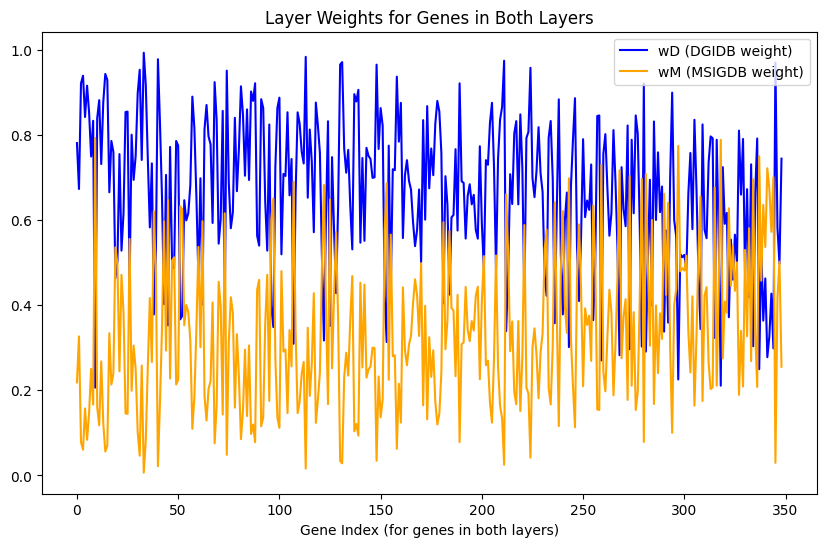

In [ ]:
# scatter plot of WD,WM
xaxis = np.arange(len(wD_list))
plt.figure(figsize=(10, 6))
plt.plot(xaxis, wD_list, color = 'blue', label='wD (DGIDB weight)')
plt.plot(xaxis, wM_list, color = 'orange', label='wM (MSIGDB weight)')
plt.xlabel('Gene Index (for genes in both layers)')
plt.legend()
plt.title('Layer Weights for Genes in Both Layers')
plt.savefig(f"../../Graphs/{DISEASE}/pairwise_weights_comparison_for_duplicated_genes.png")

### Row

In [ ]:
wD_list2 = []
total_rows = n1 + n2

rows = np.empty(total_rows, dtype=int)
cols = np.empty(total_rows, dtype=int)
data = np.empty(total_rows, dtype=P.dtype)

# DGIDB part
for didx,midx in dgidb_to_msigdb_indices_dict.items():
    rows[didx] = didx
    cols[didx] = gene_to_index_distinct[DGIDB_index_to_gene[didx]]
    if (midx is None):
        data[didx] = 1.0
    else:
        wD = pi[didx] / (pi[didx] + pi[midx + n1])
        wD_list2.append(wD)
        data[didx] = wD

wM_list2_dict = {}
# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]
    if (k in dgidb_to_msigdb_indices_dict.values()):
        # find the corresponding dgidb index
        corresponding_dgidb_idx = next(didx for didx, midx in dgidb_to_msigdb_indices_dict.items() if midx == k)
        wM = pi[n1 + k] / (pi[n1 + k] + pi[corresponding_dgidb_idx])
        wM_list2_dict[corresponding_dgidb_idx] = wM
        data[n1 + k] = wM
    else:
        data[n1 + k] = 1.0

# sparse grouping matrix
A_r = (sp.csr_matrix((data, (rows, cols)), shape=(P.shape[0], num_distinct_row))).T.tocsr()

In [ ]:
wM_list2 = [wM_list2_dict[k] for k in sorted(wM_list2_dict)]

In [ ]:
# Assert that the weights are computed the same as the graph
assert(wD_list == wD_list2 and wM_list == wM_list2)

## Build DDM

In [ ]:
def complex_square_distance_matrix(A):
    """
    Uses ||x-y||^2 = ||x||^2 + ||y||^2 - 2 Re(<x,y>)
    for complex vectors.
    """
    A = np.asarray(A, dtype=np.complex128)

    row_norms = np.sum(np.abs(A)**2, axis=1)              # shape (n,)
    G = A @ A.conj().T                                    # Gram matrix
    D = row_norms[:, None] + row_norms[None, :] - 2 * np.real(G)
    D = np.maximum(D, 0)   # clean tiny negative values from roundoff
    return D

In [ ]:
# Build diffusion matrix from eigenvalues and eigenvectors (double check)
def build_diffusion_dist_matrix(t):
    # --- SVD embedding ---
    Psi_agg = (RV * (evals_r**t)[None, :]) @ UC
    D_t2 = complex_square_distance_matrix(Psi_agg)
    print(f"t = {t} done.")
    return D_t2

def build_diffusion_dist_matrix_avg(T, mem_read = True):
    diffusion_dist_matrix = np.zeros((num_distinct_row,num_distinct_row),dtype=np.float32)
    for t in T:
        if (mem_read):
            with open(f"{OUTPUT_DIRECTORY}/diffusion_dist_matrices/ddm_{t}_itp-{interlayer_transition_prob}.npy", 'rb') as f:
                ddm = np.load(f)
        else:
            ddm = build_diffusion_dist_matrix(t)
        np.add(diffusion_dist_matrix, 
            ddm, 
            out=diffusion_dist_matrix)
        print(f"t = {t} done.")
    diffusion_dist_matrix = diffusion_dist_matrix / len(T)
    print("Finished building diffusion distance matrix.")
    np.save(f"{OUTPUT_DIRECTORY}/diffusion_dist_matrices/ddm_avg_{T}_itp-{interlayer_transition_prob}.npy",diffusion_dist_matrix)
    return diffusion_dist_matrix

## KNN Graph

In [ ]:
def build_kNN(ddm,k,sym_method='average'):
    # Choose sigma to be the median of pair-wise distance
    tmp = ddm.astype(np.float32, copy=True)
    np.sqrt(tmp, out=tmp)
    sigma = np.median(tmp[tmp != 0], overwrite_input=True)

    n = ddm.shape[0]

    # Used to indicate position of nonzero value needed to record (constructing a sparse matrix for efficiency)
    rows, cols, vals = [], [], []
    for i in range(n):
        profile = np.exp(-ddm[i] / (2* (sigma**2))) 
        idx = np.argpartition(-profile, k+1)[:k+1]  # top-k+1 (includes self)
        idx = idx[idx != i]                      # drop self
        rows += [i]*k
        cols += list(idx[:k])
        vals += list(profile[idx[:k]])
    adj_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n, n))

    # Symmetrize the matrix by adding edges to one way edges and set weight to average
    if (sym_method == 'average'):
        adj_mat = (adj_mat + adj_mat.T).multiply(0.5).tocsr()
    elif (sym_method == 'union'):
        adj_mat = adj_mat.maximum(adj_mat.T)
    elif (sym_method == 'none'):
        pass
    else:
        raise ValueError("sym_method must be 'average' or 'union'")
    
    kNN_graph = nx.from_numpy_array(adj_mat)

    
    return adj_mat,kNN_graph

In [ ]:
num_eigenvalues = 2000

In [ ]:
Path(f"{OUTPUT_DIRECTORY}/eigenvalues").mkdir(parents=True, exist_ok=True)
Path(f"{OUTPUT_DIRECTORY}/ddms").mkdir(parents=True, exist_ok=True)

In [ ]:
def apply_G(x, t):
    # Step 1: lift
    x1 = (A_r.T) @ x

    # Step 2: backward diffusion
    x2 = x1.copy()
    for _ in range(t):
        x2 = P.T @ x2

    # Step 3: collapse duplicates
    x3 = A_c @ (A_c.T @ x2) # A_c A_c^T

    # Step 4: forward diffusion
    x4 = x3.copy()
    for _ in range(t):
        x4 = P @ x4

    # Step 5: aggregate
    y = A_r @ x4

    return y

def squared_row_distance_matrix(Psi):
    norms = np.sum(Psi**2, axis=1)                                  # squared row norms
    D2 = norms[:, None] + norms[None, :] - 2 * (Psi @ Psi.T)        # pairwise squared Euclidean distances
    D2 = np.maximum(D2, 0.0)       
    
    return D2
def embedding_from_eigenpairs(evals, evecs, t):
    Psi = evecs * np.sqrt(evals)[None, :]
    return Psi

def average_aggregated_ddm(T, num_eigenvalues):
    embeddings = {}
    residual_histories = {}
    X = None
    D_avg = np.zeros((num_distinct_row,num_distinct_row),dtype=np.float64)
    
    for t in tqdm(T):
        print(f"Computing eigenpairs for t = {t}...")
        G_op = LinearOperator(
            shape=(num_distinct_row, num_distinct_row),
            matvec=lambda x: apply_G(x, t=t),
            dtype=np.float64    
        )
        if X is None:
            X = np.random.randn(num_distinct_row, num_eigenvalues) 
        
        # Compute eigenpairs using LOBPCG
        vals, vecs, residual_hist = lobpcg(
            G_op,
            X,
            largest=True,
            tol=1e-8,
            maxiter=100,
            retResidualNormsHistory=True,
        )

        residual_histories[t] = residual_hist
        print("final max residual =", np.max(residual_hist[-1]))
        print("final mean residual =", np.mean(residual_hist[-1]))
        
        vals = np.clip(vals, 0, None)
        idx = np.argsort(vals)[::-1]                                 
        vals = vals[idx]
        vecs = vecs[:, idx]
        # Save eigenvalues, eigenvectors for this t
        np.save(f"{OUTPUT_DIRECTORY}/eigenvalues/vals_{t}.npy", vals)
        np.save(f"{OUTPUT_DIRECTORY}/eigenvectors/vecs_{t}.npy", vecs)
        
        # Construct embedding                            
        Psi = embedding_from_eigenpairs(vals, vecs, t)
        
        # Check is Psi is real
        if not np.all(np.isreal(Psi)):
            raise ValueError("Warning: Some entries in the embedding are complex. Check results.")
        
        embeddings[t] = Psi
        # Save embedding for this t
        np.save(f"{OUTPUT_DIRECTORY}/embeddings/Psi_{t}.npy", Psi)
        
        # Compute diffusion distance matrix for this t and save
        D_sq_t = squared_row_distance_matrix(Psi)
        
        # Accumulate for average
        D_avg += D_sq_t
        print(f"t = {t} done.")
        
        # reuse the eigenvectors as initialization for the next t to speed up convergence
        X = vecs
        
    D_avg /= len(T)
    
    return D_avg, embeddings, residual_histories

 

In [ ]:
def check_symmetric_operator(apply_G, n, t, n_test=5, seed=0):
    rng = np.random.default_rng(seed)
    errs = []

    for _ in range(n_test):
        x = rng.standard_normal(n)
        y = rng.standard_normal(n)

        lhs = x @ apply_G(y, t)
        rhs = apply_G(x, t) @ y

        errs.append(abs(lhs - rhs))

    return errs

In [ ]:
errs = check_symmetric_operator(apply_G, num_distinct_row, t=2)
print(errs)

[6.661338147750939e-14, 1.5276668818842154e-13, 2.5757174171303632e-14, 1.5543122344752192e-13, 6.283862319378386e-14]


In [ ]:
D_avg, embeddings, residual_histories = average_aggregated_ddm(average_t, num_eigenvalues)

  0%|          | 0/4 [00:00<?, ?it/s]

Computing eigenpairs for t = 2...
final max residual = 1.7997361773655637e-10
final mean residual = 2.4860607340340733e-11


 25%|██▌       | 1/4 [1:19:58<3:59:55, 4798.56s/it]

t = 2 done.
Computing eigenpairs for t = 4...
final max residual = 8.241779125093693e-09
final mean residual = 2.1906610633889002e-10


 50%|█████     | 2/4 [3:26:52<3:35:09, 6454.79s/it]

t = 4 done.
Computing eigenpairs for t = 6...
final max residual = 4.257149875749184e-09
final mean residual = 9.195709558327676e-12


 75%|███████▌  | 3/4 [6:24:29<2:19:33, 8373.60s/it]

t = 6 done.
Computing eigenpairs for t = 8...
final max residual = 1.6806597428350933e-09
final mean residual = 1.5017469564515516e-12


100%|██████████| 4/4 [10:29:20<00:00, 9440.10s/it] 

t = 8 done.


# Error Estimation

In [ ]:
num_sample = 200

In [80]:
def apply_exact_power_left(x, t):
    y = x.copy().astype(np.complex128) 
    y = y @ A_r
    for _ in range(t):
        y = y @ P
    y = y @ A_c
    return y

def estimate_error_action(t, n_test=20, seed=0):
    # sample a pair of indices
    rng = np.random.default_rng(seed)
    
    Psi = embeddings[t]
    n = Psi.shape[0]

    abs_errs = []
    rel_errs = []

    for _ in range(n_test):
        x = np.zeros(n, dtype=np.complex128)
        y = np.zeros(n, dtype=np.complex128)
        x[rng.integers(0, n)] = 1.0
        y[rng.integers(0, n)] = 1.0
    
        row_x_exact = apply_exact_power_left(x, t) 
        row_y_exact = apply_exact_power_left(y, t) 
        d_exact = np.linalg.norm(row_x_exact - row_y_exact)**2
        
        row_x_approx = x @ Psi
        row_y_approx = y @ Psi
        d_approx = np.linalg.norm(row_x_approx - row_y_approx)**2
        
        abs_err = np.abs(d_exact - d_approx)                                     # action error                     # ||(P^t - P_t_hat)x||
        rel_err = abs_err / d_exact                # relative action error

        abs_errs.append(abs_err)
        rel_errs.append(rel_err)

    return abs_errs, rel_errs

In [ ]:
# Case Study: first two rows of P^t vs embedding approximation
# one-hot vector e1
x = np.zeros(num_distinct_row, dtype=np.complex128)
x[1123] = 1.0
y = np.zeros(num_distinct_row, dtype=np.complex128)
y[678] = 1.0
row_x_exact = apply_exact_power_left(x, 2)
row_y_exact = apply_exact_power_left(y, 2)
d_exact = np.linalg.norm(row_x_exact - row_y_exact)**2

row_x_approx = x @ embeddings[2]
row_y_approx = y @ embeddings[2]
d_approx = np.linalg.norm(row_x_approx - row_y_approx)**2

print(f"Exact distance: {d_exact}")
print(f"Approximate distance: {d_approx}")
print("relative error:", abs(d_exact - d_approx) / d_exact)


Exact distance: 0.0026455029084522888
Approximate distance: 0.002645491826471215
relative error: 4.188988429489387e-06


In [ ]:
abs_errs, rel_errs = estimate_error_action(2, n_test = num_sample)

In [ ]:
# Write median, 25th percentile, 75th percentile, max to a txt file
with open(OUTPUT_DIRECTORY + "error_log.txt", 'a') as f:
    f.write(f"Truncated power method approximation errors (t=2, num_sample = {num_sample}):\n")
    f.write(f"Median relative error: {np.median(rel_errs)}\n")
    f.write(f"25th percentile relative error: {np.percentile(rel_errs, 25)}\n")
    f.write(f"75th percentile relative error: {np.percentile(rel_errs, 75)}\n")
    f.write(f"Max relative error: {np.max(rel_errs)}\n")
    f.write("-" * 50 + "\n")

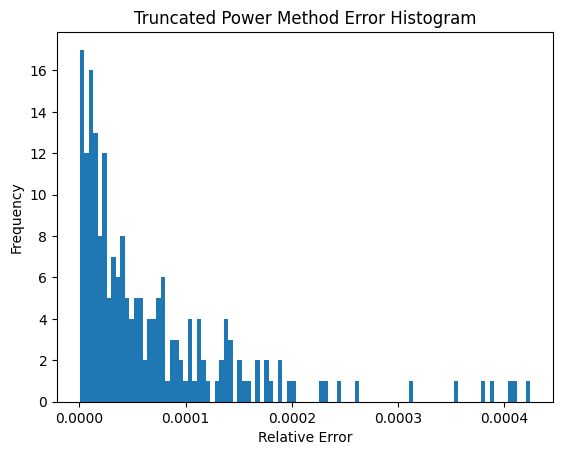

In [ ]:
plt.hist(rel_errs, bins = 100)
plt.xlabel("Relative Error")
plt.ylabel("Frequency")
plt.title("Truncated Power Method Error Histogram")
plt.savefig(f"../../Graphs/{DISEASE}/truncated_power_error_histogram_t{2}_r{num_eigenvalues}.png")

In [ ]:
def plot_subset(r_test, t, n_test=200):
    vals, vecs = np.load(f"{OUTPUT_DIRECTORY}/eigenvalues/vals_{t}.npy"), np.load(f"{OUTPUT_DIRECTORY}/eigenvectors/vecs_{t}.npy")
    Psi_subset = embedding_from_eigenpairs(vals[:r_test], vecs[:, :r_test], 2)
    rel_errs_subset = estimate_error_action(t, Psi_subset, n_test=n_test)[1]
    plt.hist(rel_errs_subset, bins = 100)
    plt.xlabel("Relative Error")
    plt.ylabel("Frequency")
    plt.title("Truncated Power Method Error Histogram")

## Choosing r

In [ ]:
vals, vecs = np.load(f"{OUTPUT_DIRECTORY}/eigenvalues/vals_2.npy"), np.load(f"{OUTPUT_DIRECTORY}/eigenvectors/vecs_2.npy")

In [ ]:
r_test = 1000
Psi_subset = embedding_from_eigenpairs(vals[0:r_test], vecs[:, 0:r_test], 2)

In [ ]:
rel_errs_subset = estimate_error_action(2, Psi_subset, n_test=200)[1]

In [ ]:
rel_errs_subset

[0.0007231377891050393,
 0.001154809055596625,
 0.005199596477076854,
 0.0010657561983341383,
 0.00027834428895401374,
 0.021382348194035578,
 0.014895179206923789,
 0.0006499813054497179,
 0.0014673996181370304,
 0.0011560728629780943,
 0.0006850592541973071,
 0.0006447531747250393,
 0.00016681646499586153,
 0.0013482854798182492,
 0.00032625598404228094,
 0.00025555316221773355,
 0.00013421599130531282,
 0.0024217866188947826,
 0.013736825929152562,
 0.004337662352651581,
 0.0007520151133907611,
 6.68597574265741e-05,
 0.006793350617529955,
 0.0015856549056621346,
 0.0016258966833816084,
 0.0074121696210222646,
 0.00039576485704790384,
 0.0024096257593510407,
 0.0017912873767239874,
 0.0005195592435126364,
 0.00047120714902495076,
 0.009960476561026011,
 0.003210426467316161,
 0.003279434123620446,
 0.000932543963574792,
 0.0019822922229390054,
 0.0038678538427766667,
 0.003759811300935623,
 0.00024321757450152708,
 8.407832075647003e-05,
 0.0018290560418260512,
 0.000230438779237564

Text(0.5, 1.0, 'Truncated Power Method Error Histogram')

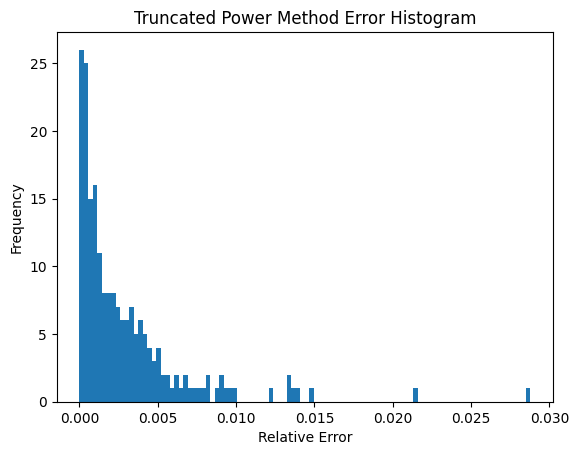

In [ ]:
plt.hist(rel_errs_subset, bins = 100)
plt.xlabel("Relative Error")
plt.ylabel("Frequency")
plt.title("Truncated Power Method Error Histogram")

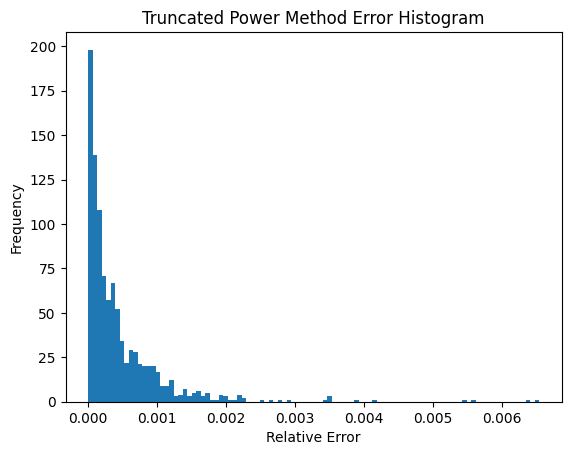

In [ ]:
plot_subset(1500, 2, n_test=200)

# Clustering Methods

In [ ]:
def igraph_from_knn_adjacency(A):
    """
    Run Leiden on a symmetric, undirected (weighted) kNN adjacency (SciPy sparse).

    Returns
    -------
    labels : np.ndarray[int]
        Community ID per node (0..k-1)
    quality : float
        Objective value (modularity / RB / CPM depending on 'method')
    """
    # Clean diagonal
    A.setdiag(0.0)
    A.eliminate_zeros()

    # Build igraph from upper triangle (each undirected edge once)
    U = sp.triu(A, k=1, format="coo")
    n = A.shape[0]
    g = ig.Graph(n=n, edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
    
    g.es["weight"] = U.data.tolist()
    
    return g

In [ ]:
resolution = 1.3

In [ ]:
part_cls = la.RBConfigurationVertexPartition
kwargs = dict(weights="weight", resolution_parameter=resolution)

In [ ]:
def leiden_from_igraph(
    g,
    *,
    n_iterations=-1,          # -1 => until no improvement
    seed=42,
):
    # Run Leiden
    part = la.find_partition(
        g,
        part_cls,
        n_iterations=n_iterations,
        seed=seed,
        **kwargs
    )

    labels = np.array(part.membership, dtype=np.int32)
    communities = [list(c) for c in part]
    return labels, float(part.quality()), communities

In [ ]:
def leiden_from_knn_adjacency(
    A,
    *, 
    n_iterations=-1,          # -1 => until no improvement
    seed=42,):
    g = igraph_from_knn_adjacency(A)
    labels, quality, communities = leiden_from_igraph(g, n_iterations=n_iterations, seed=seed)
    return labels, quality, communities

In [ ]:
def DDBC(num_neighbors,
         T):
    output_folder = f"../output/{DISEASE}/diffusion_dist_matrices"
    os.makedirs(output_folder, exist_ok=True)
    
    diffusion_dist_matrix = build_diffusion_dist_matrix_avg(T)

    kNN_adjacency_matrix, kNN_graph = build_kNN(diffusion_dist_matrix,num_neighbors)
    sp.save_npz(f"{OUTPUT_DIRECTORY}/sim_mat.npz", kNN_adjacency_matrix)

    return (*leiden_from_knn_adjacency(kNN_adjacency_matrix,n_iterations=-1,seed=42), kNN_graph, kNN_adjacency_matrix)

In [ ]:
def community_report_onepage(labels, score, out_pdf="leiden_community_report.pdf", *,
                             extra_text=None, bins="auto", title="Community Sizes", time_steps = "N/A"):
    """
    Create ONE PDF page (top: text summary, bottom: histogram).
    If out_pdf exists: append this page. Else: create it.

    Requires: matplotlib, pypdf  (pip install pypdf)
    """
    # ---- inputs ----
    labels = np.asarray(labels)
    if labels.ndim != 1:
        raise ValueError("labels must be a 1-D array of community ids")

    # ---- stats ----
    sizes = np.bincount(labels.astype(np.int64, copy=False))
    sizes_sorted = np.sort(sizes)
    n, k = sizes.sum(), sizes.size

    lines = [
        "Leiden Partition Summary",
        "========================",
        f"Nodes (n):           {n:,}",
        f"Time steps:          {time_steps}",
        f"Communities (k):     {k:,}",
        f"Size (min):          {int(sizes_sorted[0]) if k else 0:,}",
        f"Size (median):       {float(np.median(sizes_sorted)) if k else 0.0:.3f}",
        f"Size (mean):         {float(sizes_sorted.mean()) if k else 0.0:.6f}",
        f"Size (max):          {int(sizes_sorted[-1]) if k else 0:,}",
        f"Score:               {score}",
        "",
        "Top 10 largest communities (id: size):",
    ]
    for cid in np.argsort(-sizes)[:min(10, k)]:
        lines.append(f"  {int(cid):5d}: {int(sizes[cid]):,}")
    if extra_text:
        lines += ["", "Extra:", *([extra_text] if isinstance(extra_text, str) else list(extra_text))]
    summary_text = "\n".join(lines)

    # ---- draw single-page figure ----
    fig = plt.figure(figsize=(8.5, 11), dpi=150)          # US Letter, higher DPI
    ax_text = fig.add_axes([0.06, 0.55, 0.88, 0.40])      # [left, bottom, width, height]
    ax_text.axis("off")
    ax_text.text(0.0, 1.0, summary_text, va="top", ha="left", fontsize=11, family="monospace")

    ax_hist = fig.add_axes([0.10, 0.08, 0.80, 0.38])
    ax_hist.hist(sizes, bins=bins)
    ax_hist.set_xlabel("Community size")
    ax_hist.set_ylabel("Count of communities")
    ax_hist.set_title(f"Distribution of {title}")

    # ---- write this page to a temp PDF on disk ----
    with NamedTemporaryFile(delete=False, suffix=".pdf") as tmpf:
        tmp_page = Path(tmpf.name)
    with PdfPages(tmp_page) as pdf:
        pdf.savefig(fig)
    plt.close(fig)

    # ---- append/create using PdfReader/PdfWriter (robust across versions) ----
    try:
        from pypdf import PdfReader, PdfWriter
    except Exception as e:
        try: os.remove(tmp_page)
        except: pass
        raise RuntimeError("Please install 'pypdf' (e.g., `pip install pypdf`).") from e

    out_pdf = Path(out_pdf)
    tmp_out = out_pdf.with_suffix(out_pdf.suffix + ".tmp")

    writer = PdfWriter()

    # if existing, copy old pages first
    if out_pdf.exists():
        with open(out_pdf, "rb") as f_exist:
            reader = PdfReader(f_exist)
            for p in reader.pages:
                writer.add_page(p)

    # add the new single page
    with open(tmp_page, "rb") as f_new:
        reader_new = PdfReader(f_new)
        for p in reader_new.pages:
            writer.add_page(p)

    # atomic write
    with open(tmp_out, "wb") as f_out:
        writer.write(f_out)
    os.replace(tmp_out, out_pdf)

    # cleanup
    try: os.remove(tmp_page)
    except: pass

    return out_pdf


# Constructing kNN

In [ ]:
kNN_adjacency_matrix, kNN_graph = build_kNN(D_avg, k=num_neighbors, sym_method='average')

In [ ]:
kNN_adjacency_matrix.data.mean()

0.45123395251054815

# Final Average DDBC

In [ ]:
# Final Average Clustering
pdf_path = f"../output/{DISEASE}/leiden_report.pdf"
label_list = []
score_list = []
graph_list = []
communities_list = []

In [ ]:
# ddm = np.load(OUTPUT_DIRECTORY + f"")

In [ ]:
labels, score, communities = leiden_from_knn_adjacency(kNN_adjacency_matrix)
path = community_report_onepage(labels, score, out_pdf=pdf_path,
                                extra_text=[f"resolution={resolution}", f"num_neighbors = {num_neighbors}", f"interlayer_transition_probability = {interlayer_transition_prob}"], 
                                bins=100,time_steps = average_t)
print("Wrote:", path)

Wrote: ..\output\BIPOLAR\leiden_report.pdf


In [ ]:
print(communities)
with open(f"{OUTPUT_DIRECTORY}/result_communities.pkl", "wb") as f:
    pickle.dump(communities, f)
with open(f"{OUTPUT_DIRECTORY}/result_graph.pkl", "wb") as f:
    pickle.dump(kNN_graph, f)
with open(f"{OUTPUT_DIRECTORY}/labels.pkl", "wb") as f:
    pickle.dump(labels, f)     

[[30, 54, 76, 92, 94, 103, 110, 112, 128, 130, 132, 137, 140, 156, 175, 190, 198, 202, 215, 216, 231, 270, 286, 287, 290, 291, 293, 310, 312, 328, 329, 337, 338, 340, 351, 353, 382, 385, 401, 403, 417, 418, 426, 452, 457, 482, 485, 495, 538, 540, 547, 550, 551, 552, 563, 593, 600, 602, 610, 611, 613, 614, 651, 732, 734, 778, 791, 807, 815, 830, 831, 833, 858, 861, 868, 870, 874, 875, 883, 887, 889, 890, 893, 917, 956, 957, 978, 983, 991, 1006, 1016, 1019, 1024, 1037, 1097, 1114, 1165, 1205, 1207, 1208, 1240, 1271, 1273, 1275, 1290, 1293, 1309, 1353, 1358, 1379, 1389, 1390, 1413, 1414, 1447, 1457, 1472, 1515, 1525, 1526, 1528, 1551, 1571, 1591, 1600, 1638, 1659, 1662, 1711, 1712, 1717, 1720, 1727, 1728, 1765, 1766, 1768, 1771, 1772, 1774, 1778, 1785, 1792, 1793, 1809, 1828, 1836, 1860, 1877, 1883, 1884, 1912, 1917, 1918, 1919, 1920, 1921, 1933, 2009, 2024, 2059, 2063, 2072, 2074, 2077, 2148, 2163, 2166, 2212, 2278, 2288, 2289, 2294, 2310, 2316, 2331, 2406, 2491, 2492, 2493, 2498, 2508, 

# Select Communities

In [ ]:
with open(f"{OUTPUT_DIRECTORY}/result_graph.pkl", "rb") as f:
    graph = pickle.load(f)
with open(f"{OUTPUT_DIRECTORY}/result_communities.pkl", "rb") as f:
    communities = pickle.load(f)

In [ ]:
def zscore(values):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return arr

    mean = arr.mean()
    std = arr.std(ddof=0)

    if std == 0 or np.isnan(std):
        # no variation: all z-scores = 0
        return np.zeros_like(arr)

    return (arr - mean) / std

def community_central_genes_by_score(G, community_nodes, weight="weight",score_cap = 1):
    C = set(community_nodes)
    H = G.subgraph(C).copy()                       # induced subgraph
    # within-community (weighted) degree
    k = {u: H.degree(u, weight=weight) for u in H}
    ks = np.array(list(k.values()), dtype=float)
    zscore_list = zscore(ks)
    Z = dict(zip(H,zscore_list))        # within-module degree z-score

    # rank by z
    ranked = sorted(H.nodes(), key=lambda u: (Z[u]), reverse=True)
    return [u for u in ranked if Z[u] >= score_cap]

In [ ]:
# Update communities to include only the important genes, determined by a community-size_cap and z-score_cap
SIZE_CAP = 100
SCORE_CAP = 0

communities_selected = []
for community in communities:
    if (len(community) >= SIZE_CAP):
        important_nodes = community_central_genes_by_score(graph,community,score_cap = SCORE_CAP)
        a = len(important_nodes)
        b = len(community)
        print(a,b,a/b)
        communities_selected.append(important_nodes)
        
with open(f"{OUTPUT_DIRECTORY}/result_communities_selected.pkl", "wb") as f:
    pickle.dump(communities_selected, f)

909 3471 0.26188418323249785
985 3273 0.30094714329361444
1206 2855 0.42241681260945707
907 2830 0.3204946996466431
931 2280 0.4083333333333333
875 2228 0.39272890484739675
661 1393 0.4745154343144293
546 1382 0.3950795947901592
395 961 0.41103017689906346
341 492 0.693089430894309
300 406 0.7389162561576355
135 304 0.4440789473684211


In [ ]:
top_m = len(communities_selected)
print(top_m)

12


# Create graph folder

In [ ]:
os.makedirs(f"../../Graphs/{DISEASE}", exist_ok=True)

# Robustness Analysis

In [ ]:
del P, P_agg
gc.collect()

In [91]:
big_objects()

Variable                       Type                       Size (MB)
----------------------------------------------------------------------
D_avg                          ndarray                      3689.61
kNN_adjacency_matrix           csr_matrix                    177.85
C12                            ndarray                        60.20
C21                            ndarray                        60.20
coupling_matrix                ndarray                        60.20
MSIGDB_weighted_matrix         csr_matrix                      6.53
H                              csr_matrix                      6.53
MSIGDB_binary_matrix           csr_matrix                      2.77
H_bin                          csr_matrix                      2.77
msigdb                         dict                            1.25


In [92]:
# ddm = np.load(OUTPUT_DIRECTORY + f"diffusion_dist_matrices/ddm_avg_{average_t}_itp-{interlayer_transition_prob}.npy")

In [93]:
g_full = igraph_from_knn_adjacency(kNN_adjacency_matrix)

In [94]:
labels_original,_,_ = leiden_from_igraph(g_full)

In [95]:
n_boots = 1000
ari_scores = []

# === MODIFICATION START: early-stopping based on MEDIAN ARI only ===
check_every = 50   # check stability every N bootstraps
tol = 0.01        # tolerance for change in median ARI
patience = 2       # how many consecutive stable checks before stopping
prev_median = None
streak = 0
sampling_pct = 0.8
# === MODIFICATION END ===

n = kNN_adjacency_matrix.shape[0]

for b in tqdm(range(n_boots)):
    # 1. Sample genes without replacement
    idx = np.random.choice(n, size=int(sampling_pct*n), replace=False)
    sim_sub = kNN_adjacency_matrix[np.ix_(idx, idx)]
    
    g_sub = igraph_from_knn_adjacency(sim_sub)

    # 2. Recompute similarity and cluster
    labels_sub, _, _ = leiden_from_igraph(
        g_sub,
        n_iterations=-1,
        seed=42
    )

    # 3. Compare with original clustering
    ari = adjusted_rand_score(labels_original[idx], labels_sub)
    ari_scores.append(ari)

    # === MODIFICATION START: median ARI stability check ===
    if (b + 1) % check_every == 0:
        cur_median = float(np.median(ari_scores))
        print(f"Bootstrap {b+1}: Median ARI = {cur_median:.4f}")

        if prev_median is not None and abs(cur_median - prev_median) < tol:
            streak += 1
        else:
            streak = 0

        if streak >= patience:
            break

        prev_median = cur_median
    # === MODIFICATION END ===

with open(f"{OUTPUT_DIRECTORY}/bootstrap_ari_scores.txt", "w") as f:
    for score in ari_scores:
        f.write(f"{score:.4f}\n")


  5%|▌         | 50/1000 [17:28<5:37:36, 21.32s/it]

Bootstrap 50: Median ARI = 0.6914


 10%|█         | 100/1000 [32:25<4:04:17, 16.29s/it]

Bootstrap 100: Median ARI = 0.6884


 15%|█▍        | 149/1000 [56:10<5:20:52, 22.62s/it] 

Bootstrap 150: Median ARI = 0.6810


In [99]:
median_ari = np.median(ari_scores)
print("Median ARI:", median_ari)

Median ARI: 0.6809779783847008


In [97]:
# setting universal font sizes
font_size = 20
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


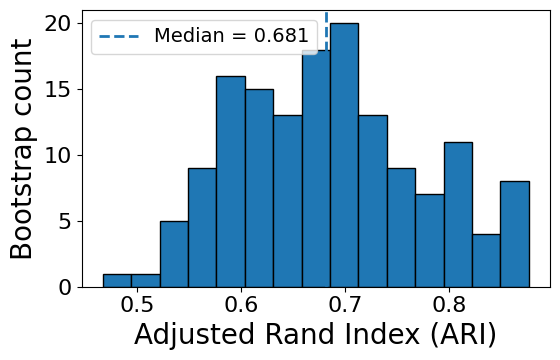

In [98]:
# === ARI stability plot ===
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(ari_scores, bins=15, edgecolor="black")
plt.axvline(median_ari, linestyle="--", linewidth=2, label=f"Median = {median_ari:.3f}")

plt.xlabel("Adjusted Rand Index (ARI)")
plt.ylabel("Bootstrap count")
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/ari_stability_plot.png", dpi=300)
plt.show()

# UMAP

In [ ]:
# def pad_rows_simple(D, n_neighbors, large=None):
#     D = D.tocsr()
#     n = D.shape[0]

#     if large is None:
#         large = D.data.max() * 1.05

#     rows_add = []
#     cols_add = []
#     vals_add = []

#     for i in range(n):
#         # current neighbors (excluding self)
#         start, end = D.indptr[i], D.indptr[i+1]
#         row_cols = D.indices[start:end]
#         row_cols = row_cols[row_cols != i]
#         deg = row_cols.size

#         if deg >= n_neighbors:
#             continue

#         need = n_neighbors - deg

#         # choose any columns except current ones + self
#         forbidden = set(row_cols.tolist() + [i])
#         candidates = [j for j in range(n) if j not in forbidden]

#         # if too few candidates, take all
#         if len(candidates) <= need:
#             chosen = candidates
#         else:
#             chosen = np.random.choice(candidates, size=need, replace=False)

#         rows_add += [i] * len(chosen)
#         cols_add += chosen if isinstance(chosen, list) else chosen.tolist()
#         vals_add += [large] * len(chosen)

#     if rows_add:
#         D = D + csr_matrix((vals_add, (rows_add, cols_add)), shape=D.shape)

#     return D

In [ ]:
# diffusion_dist_padded = pad_rows_simple(ddm_agg, n_neighbors=num_neighbors)

In [ ]:
# diffusion_dist_agg_sym = knn_symmetric(diffusion_dist_padded, sym_method="average")

In [ ]:
# def collapse_labels_top_k(labels, k=15, other_label=-1):
#     """
#     Keep only the top-k most frequent labels.
#     All other labels are replaced by `other_label`.

#     labels: 1D array-like of ints
#     k: number of most frequent labels to keep
#     other_label: label assigned to all collapsed groups

#     Returns:
#         labels_new -- collapsed label array
#         keep_map   -- mapping of kept labels to themselves
#         top_labels -- list of top-k labels
#     """
#     labels = np.asarray(labels)

#     # Count frequencies
#     freq = Counter(labels)

#     # Top-k labels by frequency
#     top_labels = [lbl for lbl, _ in freq.most_common(k)]

#     # Build new labels array
#     labels_new = np.array([
#         lbl if lbl in top_labels else other_label
#         for lbl in labels
#     ])

#     return labels_new, top_labels


In [ ]:
# labels_collapsed, top_labels = collapse_labels_top_k(labels, k=top_m, other_label=-1)

# print("Top 15 labels:", top_labels)
# print("Unique labels after collapsing:", np.unique(labels_collapsed))

In [ ]:
# with open(f"{OUTPUT_DIRECTORY}/diffusion_dist_agg_sym.pkl", "wb") as f:
#     pickle.dump(diffusion_dist_agg_sym, f)

In [ ]:
# embedding = umap.UMAP(metric='precomputed', n_neighbors=num_neighbors).fit_transform(diffusion_dist_agg_sym)

# plt.figure(figsize=(7,5))
# plt.scatter(
#     embedding[:,0],
#     embedding[:,1],
#     c=labels_collapsed,
#     cmap="tab20",
#     s=8
# )
# plt.title("UMAP embedding")
# plt.savefig(f"../../Graphs/{DISEASE}/UMAP_result.png", bbox_inches="tight")
# plt.show()


# Parameters

In [ ]:
parameters = {}

In [ ]:
# Diffusion Distance
parameters['interlayer_transition_probability (beta)'] = interlayer_transition_prob
parameters["DGIDB_weight (wD)"] = float(f"{wD:.6f}")
parameters["MSIGDB_weight (wM)"] = float(f"{wM:.6f}")
parameters["num_eigenvalues (l)"] = num_eigenvalues

# kNN and Leiden
parameters['knn_num_neighbors (k)'] = num_neighbors
parameters['leiden_resolution (gamma)'] = resolution
parameters['average_time_steps (T)'] = average_t
parameters['leiden_random_seed'] = 42

# Community Selection
parameters['community_size_cap'] = SIZE_CAP
parameters['community_zscore_cap'] = SCORE_CAP

# Bootstrap ARI
parameters['ARI_num_bootstraps'] = n_boots
parameters["ARI_num_bootstraps_executed"] = len(ari_scores)
parameters['check_every'] = 50   
parameters['tolerance_in_median_ARI_change'] = 0.01        
parameters['patience'] = 2 


with open(f"{OUTPUT_DIRECTORY}/parameters.json", "w") as f:
    json.dump(parameters, f, indent=4)